# Informe Trabajo Práctico de Laboratorio 1

## Teoría de Circuitos II

## Alumno
### Juan Manuel Miranda Del Valle

## Institución
### Universidad Tecnologica Nacional

## Profesores
### Mariano Llamedo Soria y César Fouco

### Introduccion

El presente trabajo práctico tiene como objetivo el diseño, simulación e implementación de un filtro activo del tipo Notch (rechazo de banda), especificado con una frecuencia central de rechazo de 50 hz y un ancho de banda a 3 dB de 10Hz. Este tipo de filtro resulta de particular interés práctico, ya que permite atenuar selectivamente interferencias de red eléctrica (50/60 Hz) sin afectar significativamente el resto del espectro de la señal de interés.

Para su implementación se optó por una topología Ackerberg-Mosberg, agregando una etapa sumadora a la salida. Esta arquitectura permite sintetizar la función notch a partir de la combinación de las salidas pasa-todo (la entrada) y pasa-banda, sumadas adecuadamente para obtener un cero en la frecuencia deseada.

El desarrollo del trabajo se estructuró en distintas etapas, correspondientes a las fases de diseño, simulación y validación experimental. En primer lugar, se realizó el cálculo analítico de la función transferencia y el dimensionamiento de los componentes del circuito, verificando su comportamiento mediante simulación matemática en Python y circuital en LTspice, incorporando el modelo real del amplificador operacional utilizado, con el fin de contrastar el comportamiento ideal con el que presentaría el circuito físico. A partir de este diseño validado, se procedió al armado del PCB correspondiente.

En la etapa de laboratorio, se realizó un barrido en frecuencia utilizando señales senoidales generadas con un generador de funciones, midiendo la respuesta del filtro (entrada y salida) mediante un osciloscopio digital, con el objetivo de graficar experimentalmente la curva de transferencia y compararla con la respuesta teórica y simulada. Finalmente, se empleó un analizador de espectros para verificar de manera complementaria la respuesta en frecuencia del filtro, permitiendo contrastar los resultados obtenidos por ambos métodos de medición.


#### 1. Obtener el orden del filtro y hallar la función transferencia total

<div align="center">
    <img src="1.png" width="800">
</div>

Como la consigna no pide requerimientos de atenuación mínima no teníamos ninguna limitación de un orden mínimo de filtro a usar, por lo que decidimos hacerlo de orden 2

#### 2. Obtener la transferencia de la red circuital a implementar. 

El circuito a implementar es el siguiente

<div align="center">
    <img src="2.png" width="800">
</div>

Y obtuvimos la transferencia de la siguiente forma: 



<div align="center">
    <img src="3.png" width="800">
</div>

Luego obtuvimos los valores de los componentes

<div align="center">
    <img src="4.png" width="800">
</div>

##### Entonces los componentes que elegimos para hacer el circuito

$ R1=R2= 160k\Omega $

$ R3=$ Resistencia variable hasta $50k\Omega$ medida con el multimetro antes de poner en el circuito a $ 31,83k\Omega$

El resto de las resistencias son de $ 10k\Omega $ 

Los capacitores de $ 100nF$


#### Simulación numérica/simbólica de la función transferencia en Python. 

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import scipy.signal as signal
import math as mt
# Librerías externas NumPy, SciPy y Matplotlib


# ============================================================
# 1. SIMULACIÓN SIMBÓLICA
# ============================================================

s = sp.symbols('s')
R1, R2, R3, C = sp.symbols('R1 R2 R3 C', positive=True)

# Relaciones obtenidas para el circuito
w0 = 1 / (R3*C)
Q = R2 / R3
K = R3 / R1

T = (s**2 + w0**2) / (s**2 + (w0/Q)*s + w0**2)

print("Función transferencia simbólica de -Vo/Vi:")
display(sp.Eq(-sp.Symbol("V_o") / sp.Symbol("V_i"), sp.simplify(T)))

# Forma expresada directamente mediante los componentes
T_componentes = sp.simplify(T)

print("Función transferencia en función de R2, R3 y C:")
display(sp.Eq(
    sp.Symbol("T(s)"),
    T_componentes
))


Función transferencia simbólica de -Vo/Vi:


Eq(-V_o/V_i, R2*(C**2*R3**2*s**2 + 1)/(C**2*R2*R3**2*s**2 + C*R3**2*s + R2))

Función transferencia en función de R2, R3 y C:


Eq(T(s), R2*(C**2*R3**2*s**2 + 1)/(C**2*R2*R3**2*s**2 + C*R3**2*s + R2))

In [ ]:
# 2. VALORES REALES DE LOS COMPONENTES

R1_val = 160e3       # ohm
R2_val = 160e3       # ohm
R3_val = 31.83e3     # ohm
C_val  = 100e-9      # farad

w0_val = 1 / (R3_val*C_val)
f0_val = w0_val / (2*np.pi)
Q_val = R2_val / R3_val
K_val = R3_val / R1_val

print(f"ω0 = {w0_val:.3f} rad/s")
print(f"f0 = {f0_val:.3f} Hz")
print(f"Q  = {Q_val:.4f}")
print(f"K  = {K_val:.4f}")
print(f"1/Q = {1/Q_val:.4f}")

# 3. FUNCIÓN TRANSFERENCIA NUMÉRICA

# T(s) representa -Vo/Vi
numerador = [1, 0, w0_val**2]
denominador = [1, w0_val/Q_val, w0_val**2]

print("\nNumerador:", numerador)
print("Denominador:", denominador)

ceros = np.roots(numerador)
polos = np.roots(denominador)

print("\nCeros:")
print(ceros)

print("\nPolos:")
print(polos)

In [ ]:
num = [1,0, (100*np.pi)**2]
den = [1, 20*np.pi, (100*np.pi)**2]

my_tf = signal.TransferFunction(num, den)
w = np.logspace(1, 2, 1000) * 2*np.pi
w, mag, phase = signal.bode(my_tf,w)

f = w/(2*np.pi)
plt.figure()
plt.semilogx(f, mag)
plt.xlim(10,100)
plt.title("Magnitud")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")

plt.grid(True, which="both")

plt.figure()
plt.semilogx(f, phase)
plt.title("Fase")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [°]")
plt.grid(True, which="both")

plt.show()

#### 4.Simulación circuital. Incluya el modelo real del OPAMP. 

##### Fue un desafio encontrar el modelo del OpAmp a usar dado que el fabricante da el modelo para PSpice, pero despues de un rato largo de busqueda se logro dar con el modelo indicado para el LTSpice. Vale aclarar que el modelo puesto en la simulación es el modelo del OpAmp que viene solo en un integrado por eso el nombre en la simulación es el TL081. Pero como usamos 4 de esos en la placa nosotros pusimos un TL084, que es el integrado que trae 4 OpAmp con las mismas características que el TL081

<div align="center">
    <img src="2.png" width="800">
</div>

<div align="center">
    <img src="5.png" width="1000">
</div>

### Implementacion y armado

#### En el Altium implementamos el circuito planteado e hicimos el Layout

<div align="center">
    <img src="6.png" width="1000">
</div>

<div align="center">
    <img src="7.png" width="1000">
</div>

Luego hicimos la placa con la CNC de la facultad, tuvimos varios problemas y tuvimos que hacerla 2 veces.

Inicialmente nos habíamos equivocado en el esquemático del Altium y  arrastramos ese error al layout, entrada inversora y no inversora de uno de los opamps conectadas entre si y a GND, este error hacía que a la salida vieramos la entrada. Tuvimos que hacer un puente y cortar una pista, afortunadamente no tuvimos que hacer una tercera vez la placa.

Una vez solucionado eso seguía sin funcionar correctamente por lo que haciendo una revisión más descubrimos un corto que solucionamos rapidamente, y finalmente logramos que funcione.

Cabe destacar que usamos resistores SMD con tolerancia del 1%, los capacitores de 100nF también son SMD.
Usamos conectores Bnc para facilitar la conexion a la hora de la práctica en el laboratorio.

Adjunto fotos de la placa finalizada: 

<div align="center">
    <img src="8.jpeg" width="1000">
</div>

<div align="center">
    <img src="9.jpeg" width="1000">
</div>

### Barrido en Frecuencia con el Osciloscopio

Tomamos mediciones a distintas frecuencia y reconstruimos la funcion transferencia a partir de las mediciones.

Elegimos 1Vpp para la senial de entrada. 

Nuestras mediciones se basaron en elegir distintas frecuencias, y medir tanto la amplitud de la senial de salida como el desfase temporal entre la entrada y la salida.

Para calcular la fase hice la siguiente cuenta con cada punto:

$ \phi=2\pi . Frecuencia . \Delta t $

Y para el Retardo de grupo como son puntos discretos trabaje con la diferencias de fases y de fecuencias:
$$
\tau_g(f_i)\,[\mathrm{ms}]
\approx
-\frac{1000}{2\pi}
\frac{\phi_{i}-\phi_{i-1}}
{f_{i}-f_{i-1}}
$$

Salvo el primer caso que no tiene caso anterior y entonces solo use los primeros datos 
$$
\tau_g(10Hz)\,[\mathrm{ms}]
\approx
-\frac{1000}{2\pi}
\frac{\phi_{10}}
{f_{10}}
$$

In [4]:
import pandas as pd

tabla = pd.read_clipboard(decimal=",")

display(
    tabla.style
    .format({
        "Frecuencia [Hz]": "{:.2f}",
        "Vout [mV]": "{:.0f}",
        "Vout [dB]": "{:.2f}"
    })
    .hide(axis="index")
    .set_caption("Barrido experimental en frecuencia")
)

Frecuencia [Hz],Vout [mV],Vout [dB],Delta T [mS],Fase [rad],Retardo [mS]
10.00,1000,0.00,1.200000,-0.075398,0.400000
20.00,1000,0.00,0.800000,-0.100531,1.400000
30.00,980,-0.18,1.000000,-0.188496,3.800000
40.00,980,-0.18,1.700000,-0.427257,9.800000
45.00,760,-2.38,2.600000,-0.735133,16.700000
47.00,580,-4.73,3.200000,-0.944991,3.200000
47.65,500,-6.02,3.200000,-0.958060,3.200000
48.00,400,-7.96,3.200000,-0.965097,22.800000
49.00,250,-12.04,3.600000,-1.108354,43.000000
49.25,210,-13.56,3.800000,-1.175898,-127.933333


#### Grafico de los puntos medidos 

Además uno los puntos con rectas

Frecuencia de mínimo: 50.40 Hz
Ganancia mínima: -24.44 dB


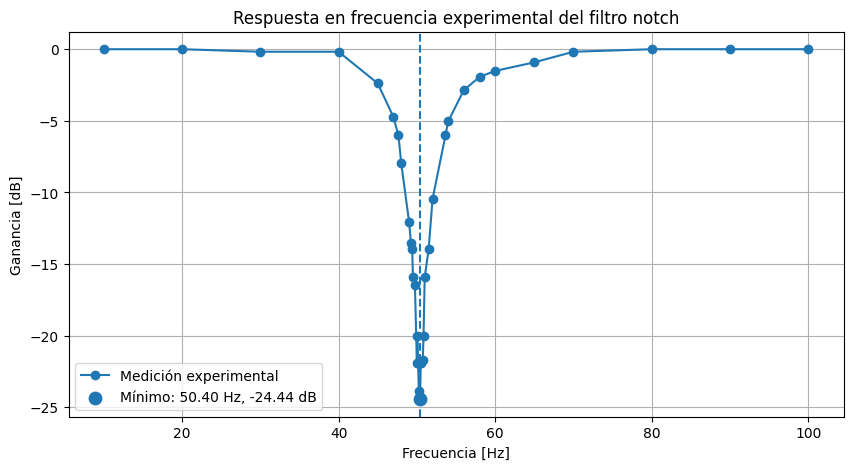

In [5]:
import matplotlib.pyplot as plt

# Ordenar la tabla por frecuencia
tabla = tabla.sort_values("Frecuencia [Hz]")

# Buscar el punto de menor ganancia
indice_minimo = tabla["Vout [dB]"].idxmin()

f_min = tabla.loc[indice_minimo, "Frecuencia [Hz]"]
db_min = tabla.loc[indice_minimo, "Vout [dB]"]

print(f"Frecuencia de mínimo: {f_min:.2f} Hz")
print(f"Ganancia mínima: {db_min:.2f} dB")

# Gráfico
plt.figure(figsize=(10, 5))

plt.plot(
    tabla["Frecuencia [Hz]"],
    tabla["Vout [dB]"],
    marker="o",
    linestyle="-",
    label="Medición experimental"
)

plt.scatter(
    f_min,
    db_min,
    s=80,
    label=f"Mínimo: {f_min:.2f} Hz, {db_min:.2f} dB"
)

plt.axvline(f_min, linestyle="--")

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Respuesta en frecuencia experimental del filtro notch")
plt.grid(True)
plt.legend()
plt.show()

#### Uso una interpolacion de PCHIP para unir los puntos por lo que hace que quede una curva mas suave.

La PCHIP es una interpolacion que usa polinomios de distintos grados para unir punto a punto sin cambios abruptos

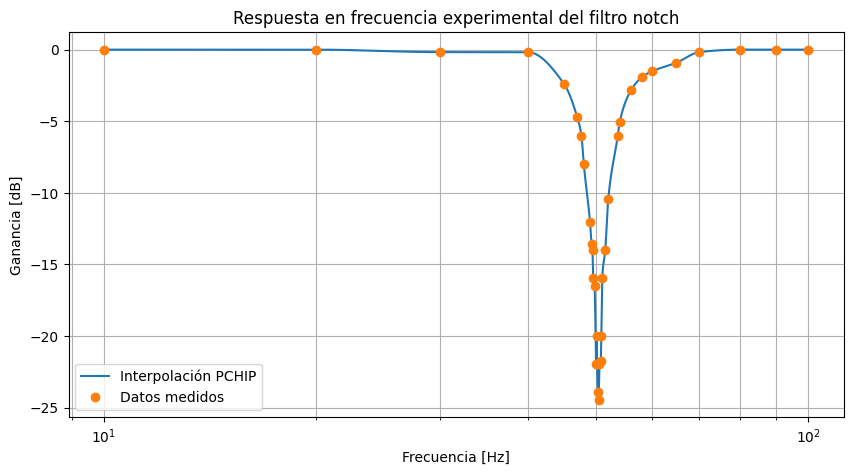

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator

# Ordenar los datos
tabla = tabla.sort_values("Frecuencia [Hz]")

f = tabla["Frecuencia [Hz]"].to_numpy()
ganancia_db = tabla["Vout [dB]"].to_numpy()

# Trabajamos con log(f) porque es una respuesta en frecuencia
log_f = np.log10(f)

# Interpolación suave
interpolador = PchipInterpolator(log_f, ganancia_db)

# Muchos puntos para dibujar la curva
f_suave = np.logspace(
    np.log10(f.min()),
    np.log10(f.max()),
    1000
)

ganancia_suave = interpolador(np.log10(f_suave))

# Gráfico
plt.figure(figsize=(10, 5))

plt.semilogx(
    f_suave,
    ganancia_suave,
    label="Interpolación PCHIP"
)

plt.semilogx(
    f,
    ganancia_db,
    "o",
    label="Datos medidos"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Respuesta en frecuencia experimental del filtro notch")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Curva fitting

Otra opcion que encontre es hacer una curva fitting que se ajuste mejor a los puntos, si bien no pasa por todos los puntos termina siendo la forma de notch que mejor se ajusta a los puntos.

Agregando los datos del filtro de la curva fitting.

Ganancia A = 1.0130
Frecuencia f0 = 50.3742 Hz
Factor Q = 4.6415
Piso de magnitud = 0.0640
Mínimo estimado = -23.87 dB
RMSE = 0.659 dB


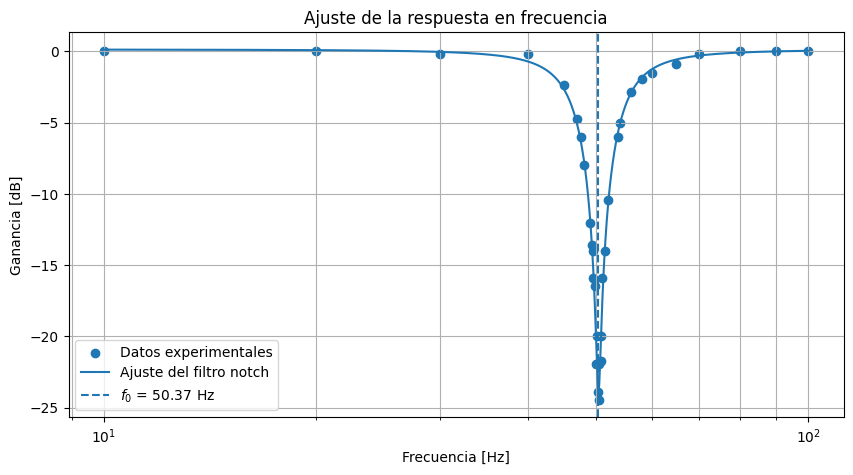

In [7]:
from scipy.optimize import curve_fit

# Modelo de magnitud de un filtro notch
def notch_db(f, A, f0, Q, piso):
    relacion = f / f0

    numerador = np.abs(1 - relacion**2)

    denominador = np.sqrt(
        (1 - relacion**2)**2
        + (relacion / Q)**2
    )

    magnitud_ideal = A * numerador / denominador

    # Contempla que experimentalmente el mínimo no llega a cero
    magnitud = np.sqrt(magnitud_ideal**2 + piso**2)

    return 20 * np.log10(magnitud)


# Estimaciones iniciales
indice_minimo = np.argmin(ganancia_db)

A_inicial = 1
f0_inicial = f[indice_minimo]
Q_inicial = 5
piso_inicial = 10**(ganancia_db[indice_minimo] / 20)

parametros, covarianza = curve_fit(
    notch_db,
    f,
    ganancia_db,
    p0=[
        A_inicial,
        f0_inicial,
        Q_inicial,
        piso_inicial
    ],
    bounds=(
        [0.5, 45, 0.1, 1e-6],
        [1.5, 55, 100, 0.5]
    ),
    maxfev=20000
)

A_ajustado, f0_ajustada, Q_ajustado, piso_ajustado = parametros

print(f"Ganancia A = {A_ajustado:.4f}")
print(f"Frecuencia f0 = {f0_ajustada:.4f} Hz")
print(f"Factor Q = {Q_ajustado:.4f}")
print(f"Piso de magnitud = {piso_ajustado:.4f}")
print(f"Mínimo estimado = {20*np.log10(piso_ajustado):.2f} dB")


# Curva suave obtenida con el ajuste
f_ajuste = np.logspace(
    np.log10(f.min()),
    np.log10(f.max()),
    2000
)

db_ajuste = notch_db(
    f_ajuste,
    A_ajustado,
    f0_ajustada,
    Q_ajustado,
    piso_ajustado
)


# Error del ajuste
db_estimados = notch_db(f, *parametros)
rmse = np.sqrt(np.mean((ganancia_db - db_estimados)**2))

print(f"RMSE = {rmse:.3f} dB")


# Gráfico
plt.figure(figsize=(10, 5))

plt.scatter(
    f,
    ganancia_db,
    label="Datos experimentales"
)

plt.semilogx(
    f_ajuste,
    db_ajuste,
    label="Ajuste del filtro notch"
)

plt.axvline(
    f0_ajustada,
    linestyle="--",
    label=f"$f_0$ = {f0_ajustada:.2f} Hz"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Ajuste de la respuesta en frecuencia")
plt.grid(True, which="both")
plt.legend()
plt.show()

Mirando la grafica podemos confirmar que nuestro filtro tiene forma de notch, y si observamos los datos obtenidos de la curva graficada se puede ver que la Fo es muy cercana a 50hz y que tambien esta cercano el valor de Q al pedido.

#### Grafico de Fase

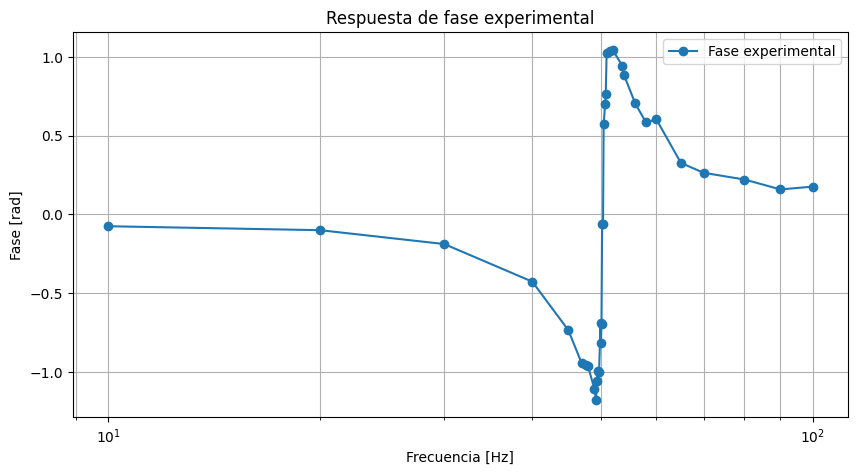

In [8]:
# GRÁFICO DE FASE
datos_fase = tabla.dropna(
    subset=["Frecuencia [Hz]", "Fase [rad]"]
)

plt.figure(figsize=(10, 5))

plt.semilogx(
    datos_fase["Frecuencia [Hz]"],
    datos_fase["Fase [rad]"],
    marker="o",
    linestyle="-",
    label="Fase experimental"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.title("Respuesta de fase experimental")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Grafico de Retardo de grupo

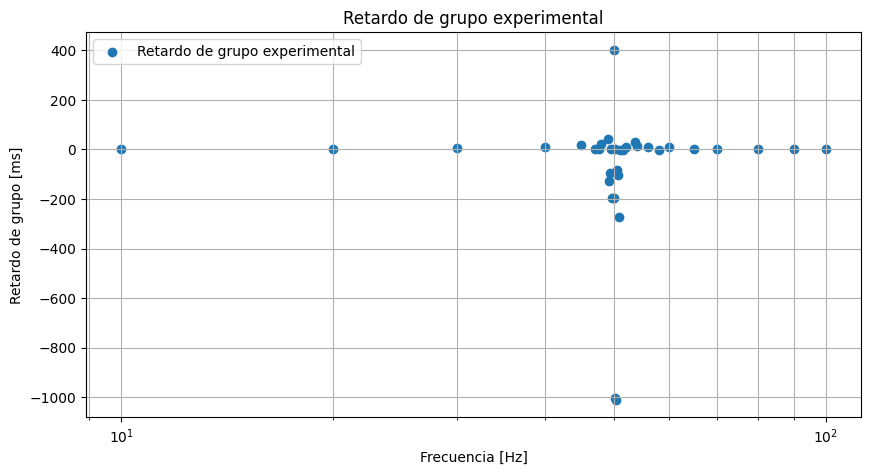

In [9]:

datos_retardo = tabla.dropna(
    subset=["Frecuencia [Hz]", "Retardo [mS]"]
)

plt.figure(figsize=(10, 5))

plt.scatter(
    datos_retardo["Frecuencia [Hz]"],
    datos_retardo["Retardo [mS]"],
    label="Retardo de grupo experimental"
)

plt.xscale("log")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Retardo de grupo [ms]")
plt.title("Retardo de grupo experimental")
plt.grid(True, which="both")
plt.legend()
plt.show()

#### Conclusiones sobre el barrido en frecuencia del osciloscopio

Puedo observar que el barrido en frecuencia coincide considerablemente con lo simulado antes de la practica en el laboratorio. Puedo decir que el filtro cumple con lo pedido correctamente.

#### Medicion en el analizador de espectros

Por ultimo hicimos una medicion el analizador de espectro y graficamos 100 puntos entre 40hz y 60hz y obtuvimos:

<div align="center">
    <img src="10.jpeg" width="1000">
</div>

Y la fase:

<div align="center">
    <img src="11.jpeg" width="1000">
</div>

Con esto confirmamos que nuestro filtro funciona bien, cumple los objetivos que queriamos que cumpliera. Con el analizador nos aseguramos de hacer un barrido mas riguroso que el barrido manual que hicimos con el osciloscopio por lo tanto nos desligamos de los errores que pudieramos tener nosotros a la hora de hacer las mediciones y el analizador grafica cada punto en la frecuencia que esta midiendo.